In [2]:
pc = 'FotR_ex'
import pandas as pd, os
import matplotlib.pyplot as plt

config = {
    'root_dir':{
        'laptop': '/home/migueljaraiz/anaconda3/repos/',
        'cluster': '/home/m.jaraiz/Documentos/DATASETS/data_TIFON/rans3_extended/outputs/',
        'pc_pro': '/home/ninjaraiz/anaconda3/repos/'
    },
    'folder_to_save':{
        'laptop': '/home/migueljaraiz/anaconda3/repos/GMM_TIFON/',
        'cluster': '/home/m.jaraiz/Documentos/GMM/GMM_TIFON/',
        'FotR_ex': './example_GMM/'
    },
    'pylom_path': {
        'laptop': '/home/migueljaraiz/anaconda3/repos/pyLowOrder',
        'cluster': '/home/m.jaraiz/repos/pyLowOrder',
        'pc_pro': '/home/ninjaraiz/anaconda3/repos/pyLowOrder'
    }   
}

for key in ['root_dir', 'pylom_path']:
    config[key]['FotR_ex'] = [path for _, path in config[key].items()]


In [3]:
def plot_case_0(case, features, n_clusters, stencil, sep, save:bool = False):
    scale = 7
    markersize_dcp = 2
    folder_name = '_'.join(features)
    df = pd.read_csv(os.path.join(config['folder_to_save'][pc], f'{folder_name}/sep_{sep}/c_{n_clusters}/s_{stencil}', 'df_data_complete.csv'), delimiter=';', index_col=0)
    def get_column_from_df(column, case, df):
        if isinstance(column, (list, tuple)):
            lista = []
            for col in column:
                lista.append(df.groupby(['aoa', 'mach']).get_group((df['aoa'].unique()[case], df['mach'].unique()[case]))[col])
            return lista
        
        if isinstance(column, str):
            serie = df.groupby(['aoa', 'mach']).get_group((df['aoa'].unique()[case], df['mach'].unique()[case]))[column]
            return serie
        
    [x, z, cp, clusters] = get_column_from_df(['x', 'z', 'cp', 'clusters_GMM'], case, df)
    list_features_log = get_column_from_df(features, case, df)
    
    fig, ax = plt.subplots(2, 1, figsize=(8, 2*4))
    # ax = ax.flatten()
    ax[0].scatter(
        x, z,
        c='black', s=1
    )
    # Hacer tantos scatters en twinx como features haya y poner tantos colores de una tableta como n_features haya
    colores = plt.get_cmap('tab10').colors
    for _, (feature, color)in enumerate(zip(list_features_log, colores)):
        ax_twin = ax[0].twinx()
        ax_twin.scatter(
            x, feature, s=markersize_dcp, c=color
        )
        ax_twin.set_yscale('symlog')
        ax_twin.spines['right'].set_position(('outward', 30 +_ * 30))
        ax_twin.spines['right'].set_color(color)
        ax_twin.tick_params(axis='y', colors=color)

    # ax01 = ax[0].twinx()
    # ax01.scatter(
    #     x, list_features_log[1], c='red', s=markersize_dcp
    # )
    ax[0].set_ylim(bottom = z.min()*scale, top = z.max()*scale)
    # Poner un tercer eje a la izquierda con cp
    ax_cp = ax[0].twinx()
    ax_cp.scatter(
        x, cp, c='green', s=markersize_dcp
    )
    ax_cp.spines['left'].set_position(('outward', 60))
    ax_cp.spines['left'].set_color('green')
    ax_cp.tick_params(axis='y', colors='green')
    ax_cp.invert_yaxis()
    ax_cp.yaxis.set_label_position('left')
    ax_cp.yaxis.tick_left()
    ax_cp.spines['right'].set_visible(False)
    
    # # Arreglar ejes de los twinx
    # ax00.set_yscale('symlog')
    # ax01.set_yscale('symlog')
    # #separar ejes secundarios y poner del mismo color que los puntos
    # ax00.spines['right'].set_position(('outward', 30))
    # ax01.spines['right'].set_position(('outward', 90))
    # ax00.spines['right'].set_color('blue')
    # ax01.spines['right'].set_color('red')
    # ax00.tick_params(axis='y', colors='blue')
    # ax01.tick_params(axis='y', colors='red')
    ax[0].set_xlabel('x')
    ax[0].set_ylabel('z')
    # ax00.set_ylabel(features[0], color='blue')
    # ax01.set_ylabel(features[1], color='red')
    ax[0].set_title(f'Case {case}')

    ax[1].scatter(
        x, z, c='black', s=1, alpha=0.7)
    ax[1].set_xlabel('x')
    ax[1].set_ylabel('z')
    ax[1].set_ylim(z.min() - 0.1, z.max() + 0.1)
    ax10 = ax[1].twinx()
    ax10.scatter(
        x, cp, c=clusters, s=markersize_dcp, alpha=0.7, cmap='viridis')
    ax10.set_ylabel('cP')
    ax10.invert_yaxis()

    fig.suptitle(f'Case {case} - features: {features} - sep: {sep} - stencil: {stencil}')
    # bajar título para que no se solape con los ejes
    fig.subplots_adjust(top=0.9)
    if bool(save):
        fig.savefig(
            os.path.join(
                config['folder_to_save'][pc], f'{folder_name}/sep_{sep}/c_{n_clusters}/example_case{case}_s_{stencil}.png'
                )
            )
        plt.close('all')
    else:
        return fig


def make_gif_from_case(case:int, features:list, n_clusters:int, sep:int):
    import imageio
    folder_name = '_'.join(features)
    folder_path = os.path.join(config['folder_to_save'][pc], f'{folder_name}/sep_{sep}/c_{n_clusters}')
    if not os.path.exists(folder_path):
        raise ValueError(f'Folder {folder_path} does not exist. Please run the clustering first.')
    list_fig = []
    for folder in os.listdir(folder_path):
        if folder.startswith('s_'):
            stencil = int(folder.split('_')[-1])
            stencil_folder = os.path.join(folder_path, folder)
            if not os.path.exists(stencil_folder):
                raise ValueError(f'Folder {stencil_folder} does not exist. Please run the clustering first.')
            
            fig = plot_case_0(case, features, n_clusters, stencil, sep, save=False)
            list_fig.append(fig)
    
    # Save the figures as a gif
    gif_path = os.path.join(folder_path, f'case_{case}_features_{"".join(features)}_sep_{sep}_clusters_{n_clusters}.gif')
    with imageio.get_writer(gif_path, mode='I', duration=1.5) as writer:
        for fig in list_fig:
            # Save the figure to a temporary file
            temp_path = os.path.join(folder_path, 'temp.png')
            fig.savefig(temp_path)
            plt.close(fig)
            # Read the image and append it to the gif
            image = imageio.imread(temp_path)
            writer.append_data(image)
            # Remove the temporary file
            os.remove(temp_path)
            
def var_to_features(vars):
    return [f'd{var}_ds_log' for var in vars]

/tmp/ipykernel_3027526/596290313.py:30: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax_twin.scatter(


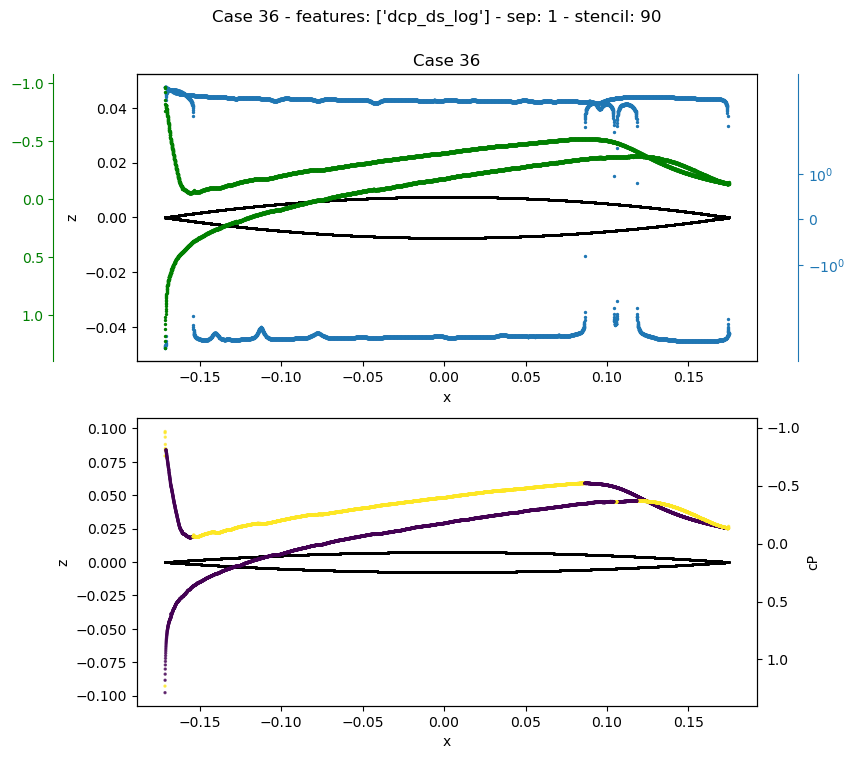

In [5]:
vars = ['cp']#, 'cp2'] # , 'gradrhox_log', 'gradTx_log'
# features = ['drho_ds_log', 'drho2_ds_log'] 

features = var_to_features(vars)


stencil = 90
sep=1
n_clusters=2

case=36
fig1 = plot_case_0(
    case=case, features=features,
    n_clusters=n_clusters,
    stencil=stencil, sep=sep,
    save=False
    )
# n_clusters=2
# fig2 = plot_case_0(
#     case=case, features=features,
#     n_clusters=n_clusters,
#     stencil=stencil, sep=sep,
#     save=False
#     )


In [ ]:
vars = ['cp', 'cp2', 'rho', 'rho2', 'T', 'T2'] # , 'gradrhox_log', 'gradTx_log'
features = var_to_features(vars)
stencil = 150
sep=1
n_clusters=2

case=36
fig1 = plot_case_0(
    case=case, features=features,
    n_clusters=n_clusters,
    stencil=stencil, sep=sep,
    save=False
    )
# n_clusters=2
# fig2 = plot_case_0(
#     case=case, features=features,
#     n_clusters=n_clusters,
#     stencil=stencil, sep=sep,
#     save=False
#     )

In [ ]:
make_gif_from_case(case=36, features=features, n_clusters=2, sep=1)

In [ ]:
import os
import io

import imageio.v2 as imageio
import matplotlib.pyplot as plt

from matplotlib.widgets import Slider


def view_case_with_slider(case: int,
                          features: list,
                          n_clusters: int,
                          sep: int):
    """
    Muestra de forma interactiva todos los stencils mediante un Slider.
    También permite avanzar y retroceder con las flechas izquierda y derecha.
    """

    folder_name = "_".join(features)

    folder_path = os.path.join(
        config["folder_to_save"][pc],
        f"{folder_name}/sep_{sep}/c_{n_clusters}"
    )

    if not os.path.exists(folder_path):
        raise ValueError(f"Folder {folder_path} does not exist.")

    # ==========================================================
    # Cargar todas las figuras como imágenes
    # ==========================================================

    images = []
    stencils = []

    folders = sorted(
        [f for f in os.listdir(folder_path) if f.startswith("s_")],
        key=lambda x: int(x.split("_")[-1])
    )

    for folder in folders:

        stencil = int(folder.split("_")[-1])

        fig = plot_case_0(
            case=case,
            features=features,
            n_clusters=n_clusters,
            stencil=stencil,
            sep=sep,
            save=False,
        )

        buffer = io.BytesIO()
        fig.savefig(buffer, format="png", dpi=150)
        plt.close(fig)

        buffer.seek(0)

        images.append(imageio.imread(buffer))
        stencils.append(stencil)

    # ==========================================================
    # Crear visor
    # ==========================================================

    fig, ax = plt.subplots(figsize=(6, 6))
    plt.subplots_adjust(bottom=0.15)

    im = ax.imshow(images[0])
    ax.axis("off")
    ax.set_title(f"Stencil = {stencils[0]}")

    # Slider
    ax_slider = plt.axes([0.15, 0.05, 0.7, 0.03])

    slider = Slider(
        ax=ax_slider,
        label="Frame",
        valmin=0,
        valmax=len(images) - 1,
        valinit=0,
        valstep=1,
    )

    # ----------------------------------------------------------
    # Actualizar imagen
    # ----------------------------------------------------------

    def update(val):
        i = int(slider.val)
        im.set_data(images[i])
        ax.set_title(f"Stencil = {stencils[i]}")
        fig.canvas.draw_idle()

    slider.on_changed(update)

    # ----------------------------------------------------------
    # Control mediante teclado
    # ----------------------------------------------------------

    def on_key(event):

        i = int(slider.val)

        if event.key == "right":
            slider.set_val(min(i + 1, len(images) - 1))

        elif event.key == "left":
            slider.set_val(max(i - 1, 0))

    fig.canvas.mpl_connect("key_press_event", on_key)

    plt.show()

In [ ]:
%matplotlib widget
view_case_with_slider(case=87, features=features, n_clusters=2, sep=1)

In [ ]:
for case in [87, ]:
    fig = plot_case_0(
        case = case, # 36, 87, 72, 78
        features=features,
        n_clusters = 2,
        stencil = 10,
        sep = 1,
        save = False
    )
    fig = plot_case_0(
        case = case, # 36, 87, 72, 78
        features=features,
        n_clusters = 2,
        stencil = 100,
        sep = 1,
        save = False
    )
    
    fig = plot_case_0(
        case = case, # 36, 87, 72, 78
        features=features,
        n_clusters = 2,
        stencil = 190,
        sep = 1,
        save = False
    )